# <center>AI1013: Programming for AI</center>
## <center>Assignment - 3</center>

### 1. Dataset Construction

#### Importing required modules

In [34]:
import numpy as np
import torch
from torch.nn.functional import relu
import matplotlib.pyplot as plt

Data Genearation

In [35]:
#1D input values
X = torch.linspace(-10,10,500)

#sin of X
sinX = torch.sin(X)

#calculating sinC
sinC = sinX / X

#if X==0, then sinc(X)=1, else sin(x) / x
sinC = torch.where(X==0, 1, sinC)

#adding gaussian noise (mean=0, var=0.01)
sinC_noisy = sinC + 0.1*torch.randn(sinC.shape)

#resizing for training the model
X = X.reshape(-1,1)
sinC_noisy = sinC_noisy.reshape(-1,1)

Visualisation

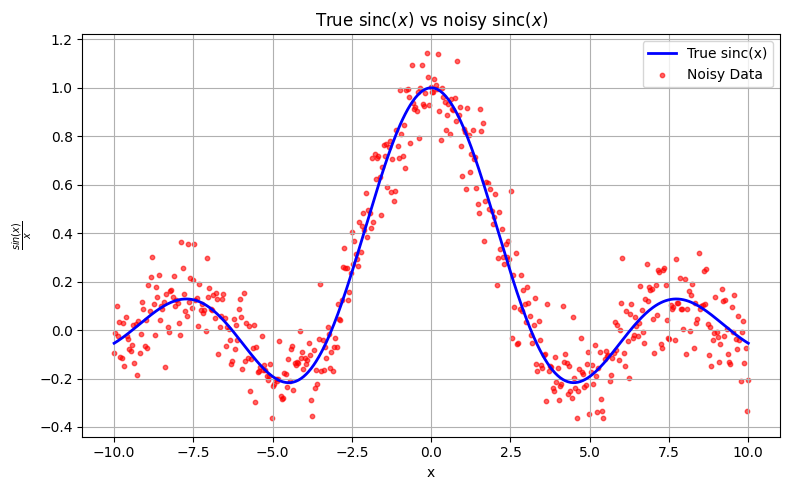

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(X, sinC, label='True sinc(x)', color='blue', linewidth=2)
plt.scatter(X, sinC_noisy, label='Noisy Data', color='red', s=10, alpha=0.6)

plt.title(r'True $\operatorname{sinc}(x)$ vs noisy $\operatorname{sinc}(x)$')
plt.xlabel('x')
plt.ylabel(r'$\frac{sin(x)}{x}$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 2.Multilayer Perceptron (MLP) with Two Hidden Layers

#### Model Architecure and setup

Defining MLP Model

In [37]:
class MLP(torch.nn.Module):
    def __init__(self, n_hidden1=3, n_hidden2=3):
        super(MLP, self).__init__()

        #linear layer(input (single number) -> n_hidden1)
        self.fc1 = torch.nn.Linear(1, n_hidden1)

        #linear layer (n_hidden1 -> n_hidden2)
        self.fc2 = torch.nn.Linear(n_hidden1, n_hidden2)

        #linear layer (n_hidden2 -> output (single number))
        self.fc3 = torch.nn.Linear(n_hidden2, 1)

    def forward(self,x):
        #pass to hidden layer1
        x = relu(self.fc1(x))

        #passing to hidden layer2
        x = relu(self.fc2(x))

        #passing to output
        x = self.fc3(x)

        return x

Hyperparameters setup

In [38]:
#creating our instance of MLP
model = MLP(30,30)

batch_size = 64
learning_rate = 0.02 #users choice
num_epochs = 100 # users choice


loss_function = torch.nn.MSELoss()


optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) #users choice

#### Trainig the MLP

Data Preparation

In [39]:
#wrapping the data in a dataset
dataset = torch.utils.data.TensorDataset(X, sinC_noisy)

#creating a dataloader
dataloader = torch.utils.data.DataLoader(dataset, shuffle=True, batch_size=batch_size)

Training Loop

In [40]:
training_loss = [] #to store losses and visualise later


#looping
for epoch in range(num_epochs):
    current_loss = 0.0

    for x,y in dataloader:
        #forward pass
        predicted = model(x)

        #calculating loss
        loss = loss_function(predicted, y)

        #going backward
        optimizer.zero_grad() #clear previous gradients if any
        loss.backward()
        optimizer.step()

        #keeping total loss
        current_loss += loss.item()

    training_loss.append(current_loss / len(dataloader))

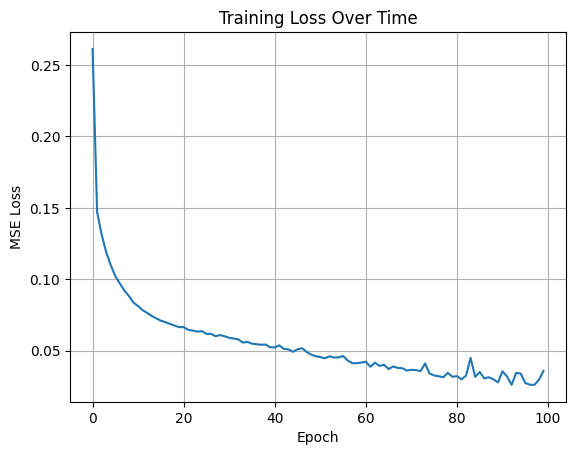

np.float64(0.026040099561214447)

In [41]:
plt.plot(training_loss)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Time")
plt.grid(True)
plt.show()

np.array(training_loss).min()

#### Decision Boundary visualization

Generating a Mesh Grid

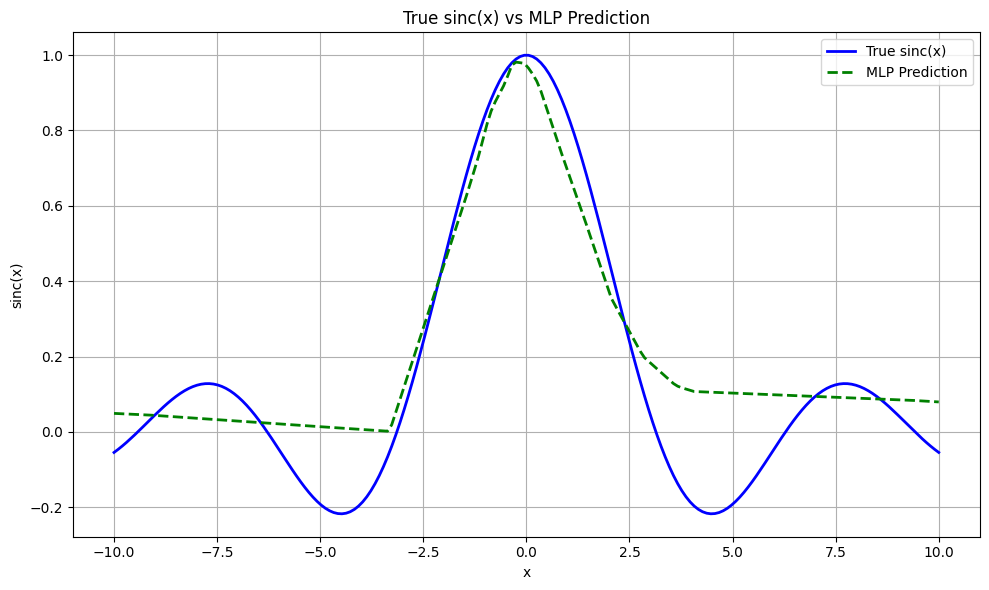

In [42]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Generate input grid (same as training range)
x_vals = np.linspace(-10, 10, 200)
X_grid = torch.tensor(x_vals, dtype=torch.float32).reshape(-1, 1)

# Compute true sinc values
true_sinc = torch.where(X_grid == 0, torch.tensor(1.0), torch.sin(X_grid) / X_grid)

# Predict using the trained model
model.eval()
with torch.no_grad():
    predicted_sinc = model(X_grid)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_vals, true_sinc.numpy(), label='True sinc(x)', color='blue', linewidth=2)
plt.plot(x_vals, predicted_sinc.numpy(), label='MLP Prediction', color='green', linestyle='--', linewidth=2)
plt.title("True sinc(x) vs MLP Prediction")
plt.xlabel("x")
plt.ylabel("sinc(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 3.Introduction to CNN

#### Data Preparation

Making the dataset class

In [66]:
import os
from PIL import Image
from torchvision import transforms

#defining the transform
transform = transforms.Compose([
    transforms.ToTensor(),
])

class RPSDataset(torch.utils.data.Dataset):
    def __init__(self, img_folder):
        self.img_folder = img_folder
        self.classes = ["rock", "paper", "scissors"]
        self.labels = [] #it will have the label of each image
        self.img_paths =[] #it will have the img path for the corresponding image

        index=0 #for class index 
        for classname in self.classes:
            #images are in folder named as "rock", "paper", "scissors"
            class_folder = os.path.join(self.img_folder, classname)

            #keeping a track of all images in this label
            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)
                self.img_paths.append(img_path) #storing the path
                self.labels.append(index) #storing the label corresponding to current image

            index+=1 #next label 
    
    #to get the image at a particular index
    def __getitem__(self, index):
        image_path, label = self.img_paths[index], self.labels[index]

        image = Image.open(image_path)

        return image, label

    
    #to get how many images we have
    def __len__(self):
        return len(self.labels)


Splitting the data into training and test sets

In [47]:
#creating an instance of our dataloader
import torch.utils.data.dataloader


dataset = RPSDataset( "./rps-cv-images")

#doing a 70-30 split
trainsize = int(0.7*len(dataset))
testsize = int(len(dataset) -trainsize)

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [trainsize, testsize])

#now we have our dataset split into train and test
#lets initialize dataloaders
batch_size = 32
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size= batch_size, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size= batch_size)

### Understanding Covolutions

creating the CNN Class for understanding

In [ ]:
class CNN_learn(torch.nn.Module):
    def __init__(self, in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=1):
        super(CNN_learn, self).__init__()
        self.conv = torch.nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding)

    def forward(self, x):
        return self.conv(x)

We have defined our class, lets play around with it.

First, let's define the kernels that we are going to use

In [190]:
#defining our kernels
blur_kernel = torch.tensor([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0) 

edge_kernel = torch.tensor([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)


sharpen_kernel = torch.tensor([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0) 

kernels = [blur_kernel, edge_kernel, sharpen_kernel]
kernel_names = ["Blur", "Edge", "Sharpen"]

Lets select a image and check the input and output dimensions

In [161]:

#selecting a image
image_path = "./rps-cv-images/rock/00nKV8oHuTGi20gq.png"

#opening
image = Image.open(image_path).convert("RGB")

#applying transform
image_tensor = transform(image).unsqueeze(0)

print("Input shape : ", image_tensor.size())
model = CNN_learn(in_channels=3, out_channels=1, kernel_size=3, padding=1,stride=1)
output = model(image_tensor)
print("Output shape : ", output.size())

Input shape :  torch.Size([1, 3, 200, 300])
Output shape :  torch.Size([1, 1, 200, 300])


The input shape and output shape do match. Since we are using padding=1, and strid =1, the original dimension of the image is preserved. Also, in_channels = 3, but out_channels = 1 is also visible from the output. 

Let's now apply different kernels and visualize the feature maps

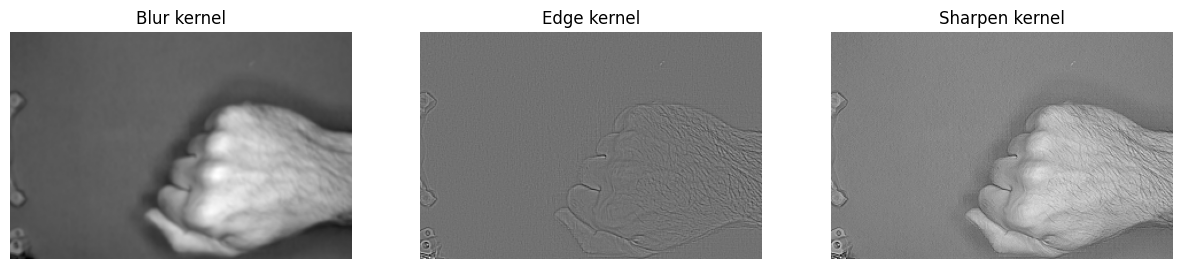

In [197]:
fig_basic, axes_basic = plt.subplots(1,3,figsize=(15,5))
for i in range(3):
    model = CNN_learn(in_channels=3, out_channels=1, kernel_size=3, padding=0,stride=1)
    with torch.no_grad():
        model.conv.weight.copy_(kernels[i])

    #applying convolution
    output = model(image_tensor)
    feature_map = output.squeeze(0)
    feature_map_permuted = feature_map.permute(1,2,0).detach().numpy()

    axes_basic[i].imshow(feature_map_permuted, cmap="gray")
    axes_basic[i].axis('off')
    axes_basic[i].set_title(kernel_names[i]+" kernel")

This is self-explanatory, lets try to modify padding, stride and kernel_size and see how it works

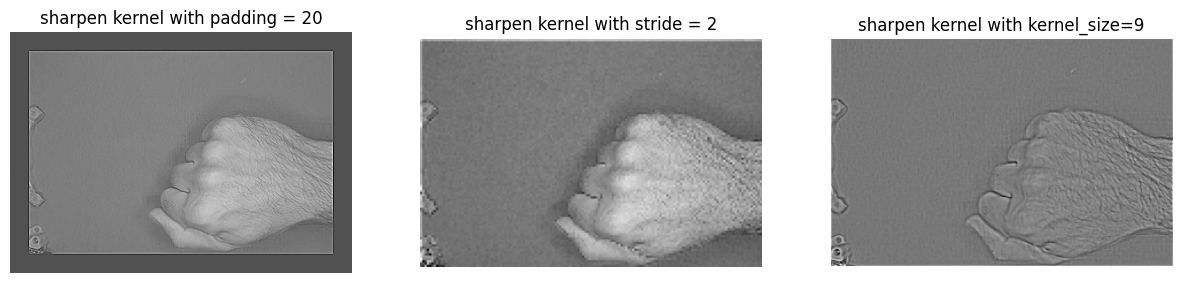

In [204]:
figs_modified_params, axes_modified_params = plt.subplots(1,3, figsize=(15,5))

###########################
###padding modificiation###
###########################
model = CNN_learn(in_channels=3, out_channels=1, kernel_size=3, padding=20,stride=1)
with torch.no_grad():
    model.conv.weight.copy_(kernels[i])

#applying convolution
output = model(image_tensor)
feature_map = output.squeeze(0)
feature_map_permuted = feature_map.permute(1,2,0).detach().numpy()

axes_modified_params[0].imshow(feature_map_permuted, cmap="gray")
axes_modified_params[0].axis('off')
axes_modified_params[0].set_title("sharpen kernel with padding = 20")

###########################
####stride modification####
###########################
model = CNN_learn(in_channels=3, out_channels=1, kernel_size=3, padding=1,stride=2)
with torch.no_grad():
    model.conv.weight.copy_(kernels[i])

#applying convolution
output = model(image_tensor)
feature_map = output.squeeze(0)
feature_map_permuted = feature_map.permute(1,2,0).detach().numpy()

axes_modified_params[1].imshow(feature_map_permuted, cmap="gray")
axes_modified_params[1].axis('off')
axes_modified_params[1].set_title("sharpen kernel with stride = 2")

###########################
####kernel modification####
###########################
model = CNN_learn(in_channels=3, out_channels=1, kernel_size=5, padding=1,stride=1)

#making the kernels
sharpen_kernel_5ks = -1 * torch.ones((5, 5))
sharpen_kernel_5ks[2, 2] = 25

blur_kernel_5ks = torch.ones((5,5)) / (25)

edge_kernel_5ks = -1 * torch.ones((5, 5))
edge_kernel_5ks[2, 2] = 24 

#aaplying the kernel
with torch.no_grad():
    model.conv.weight.copy_(sharpen_kernel_5ks)


#applying convolution
output = model(image_tensor)
feature_map = output.squeeze(0)
feature_map_permuted = feature_map.permute(1,2,0).detach().numpy()

axes_modified_params[2].imshow(feature_map_permuted, cmap="gray")
axes_modified_params[2].axis('off')
axes_modified_params[2].set_title("sharpen kernel with kernel_size=9")

plt.show()

The image outputs help us visualise how does these parameters work. \
Increasing the padding helps the model to easily work with the edge pixels. \
Increasing the stride reduces the feture map's quality, as it skips more pixels. \
Increasing the kernel size, increases the effect of kernel, like making it more sharp or more blurry.

### Pooling Functions